# Single AI Agent: Search + Weather (LangChain 1.x)

An **agent** is an LLM running in a loop: it reads the question, decides whether to call a **tool**, reads the tool's result, and repeats until it can answer.

```
user question -> LLM -> tool call? --yes--> run tool -> result back to LLM -> ...
                           |
                           no -> final answer
```

We build it in 6 steps. Run each cell and read its output before moving on.

## Step 1: Load API keys

Keys live in `.env` (project root), never in code. `load_dotenv` copies them into `os.environ`, where LangChain integrations read them automatically.

> Old code also set `SSL_CERT_FILE` with `certifi`. That was a fix for Windows Anaconda; not needed here.

In [1]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(usecwd=True))  # searches upward, so it finds ../.env

for key in ["GROQ_API_KEY", "OPENAI_API_KEY", "TAVILY_API_KEY", "WEATHERSTACK_API_KEY"]:
    print(f"{key:22} {'set' if os.getenv(key) else 'missing'}")

GROQ_API_KEY           set
OPENAI_API_KEY         missing
TAVILY_API_KEY         set
WEATHERSTACK_API_KEY   set


## Step 2: The LLM (the agent's brain)

`init_chat_model("provider:model")` gives one interface for any provider. Swap the string to change the model; the rest of the code stays the same.

| Old | New |
|---|---|
| `ChatOpenAI(model="gpt-3.5-turbo")` | `init_chat_model("openai:gpt-4o-mini")` (gpt-3.5 is retired) |

The model must support **tool calling** (all modern ones do).

In [4]:
from langchain.chat_models import init_chat_model

MODEL = "groq:openai/gpt-oss-120b"  # free. With an OpenAI key: "openai:gpt-4o-mini"

llm = init_chat_model(MODEL, temperature=0)
response = llm.invoke("Tell me a joke about humanity")
print(response.content)

Sure, here’s a light‑hearted one:

Why did humanity apply for a job at the bakery?

Because we heard there’s a lot of “dough” to be made, and we’re already great at rising to the occasion! 😄


## Step 3: Tool 1 - web search (Tavily)

A **tool** = a function + a name + a description. The LLM never runs code itself; it only *asks* for a tool by name with arguments, and the agent runs it.

| Old | New |
|---|---|
| `from langchain_community.tools.tavily_search import TavilySearchResults` | `from langchain_tavily import TavilySearch` |

In [5]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(max_results=2)

result = search_tool.invoke("latest news on AI")
for r in result["results"]:
    print(r["title"], "->", r["url"])

AI News | Latest News | Insights Powering AI-Driven Business Growth -> https://www.artificialintelligence-news.com
Artificial Intelligence - Latest AI News and Analysis - WSJ.com -> https://www.wsj.com/tech/ai


## Step 4: Tool 2 - your own tool with `@tool`

`@tool` turns a normal function into a tool. LangChain sends the LLM:
- the **function name** -> tool name
- the **docstring** -> when to use it (write it for the LLM!)
- the **type hints** -> argument schema (`city: str`)

Improvements over the old version: `params=` encodes spaces in "New Delhi", `timeout=` stops hangs, and errors are returned as text so the agent can recover instead of crashing.

In [9]:
import requests
from langchain.tools import tool


@tool
def get_weather_data(city: str) -> str:
    """Get the current weather (temperature, conditions, humidity) for a city."""
    try:
        response = requests.get(
            "https://api.weatherstack.com/current",
            params={"access_key": os.getenv("WEATHERSTACK_API_KEY"), "query": city},
            timeout=10,
        )
        data = response.json()
    except requests.RequestException as e:
        return f"Weather service error: {e}"

    if "current" not in data:
        return f"Could not fetch weather data for {city}: {data.get('error', {}).get('info', 'unknown error')}"

    current = data["current"]
    return (
        f"City: {city}\n"
        f"Temperature: {current['temperature']}°C\n"
        f"Weather: {current['weather_descriptions'][0]}\n"
        f"Humidity: {current['humidity']}%"
    )


print(get_weather_data.name, "|", get_weather_data.description)
print(get_weather_data.args)
print(get_weather_data.invoke({"city": "New Delhi"}))

get_weather_data | Get the current weather (temperature, conditions, humidity) for a city.
{'city': {'title': 'City', 'type': 'string'}}
City: New Delhi
Temperature: 35°C
Weather: Clear
Humidity: 24%


## Step 5: Create the agent

This is the biggest change. Old LangChain needed **three** pieces; now it is **one** call.

| Old (0.x) | New (1.x) |
|---|---|
| `prompt = hub.pull("hwchase17/react")` | `system_prompt="..."` (optional) |
| `agent = create_react_agent(llm, tools, prompt)` | `agent = create_agent(llm, tools, system_prompt=...)` |
| `AgentExecutor(agent=agent, tools=tools, verbose=True)` | not needed: the agent runs its own loop |

**Why the hub prompt is gone:** the old ReAct prompt made the LLM *write* `Action: ... Action Input: ...` as plain text, which LangChain then parsed (fragile). Modern models have native **tool calling**: they return a structured tool call, so no special prompt or parsing is needed.

Under the hood `create_agent` builds a **LangGraph** graph: a `model` node and a `tools` node in a loop.

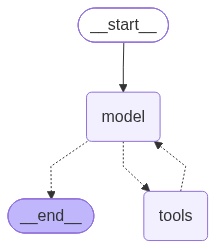

In [10]:
from langchain.agents import create_agent

tools = [search_tool, get_weather_data]

agent = create_agent(
    llm,
    tools=tools,
    system_prompt="You are a helpful assistant. Use tools for current facts. If a tool returns an error, tell the user instead of retrying. Be concise.",
)
agent

## Step 6: Run it

The agent's state is a list of **messages**. Input and output are both `{"messages": [...]}`.

| Old | New |
|---|---|
| `agent_executor.invoke({"input": "..."})` | `agent.invoke({"messages": [("user", "...")]})` |
| `response["output"]` | `result["messages"][-1].content` |
| `AgentExecutor(max_iterations=...)` | `config={"recursion_limit": N}` |
| `verbose=True` | `agent.stream(..., stream_mode="values")` and print each step |

Watch the message types: **Human** -> **AI** (with tool calls) -> **Tool** (results) -> ... -> **AI** (final answer).

In [11]:
question = "Find the capital of India and then find its current weather."

config = {"recursion_limit": 10}  # max graph steps: a safety net against endless tool loops

for step in agent.stream({"messages": [("user", question)]}, config, stream_mode="values"):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Find the capital of India and then find its current weather.
================================== Ai Message ==================================
Tool Calls:
  get_weather_data (fc_db610819-3307-4229-8eee-c1a9c16bdfee)
 Call ID: fc_db610819-3307-4229-8eee-c1a9c16bdfee
  Args:
    city: New Delhi
================================= Tool Message =================================
Name: get_weather_data

City: New Delhi
Temperature: 35°C
Weather: Clear
Humidity: 24%
================================== Ai Message ==================================

The capital of India is **New Delhi**.  

Current weather in New Delhi: **35 °C**, clear skies, humidity **24 %**.


In [12]:
# Or just get the final answer
result = agent.invoke({"messages": [("user", question)]}, config)
print(result["messages"][-1].content)

The capital of India is **New Delhi**.  

Current weather in New Delhi: **35 °C**, clear skies, humidity **24 %**.


## Recap

1. **LLM** = brain, picked by a `"provider:model"` string.
2. **Tools** = functions the LLM may request; the docstring tells it when.
3. **Agent** = `create_agent(llm, tools)`: a LangGraph loop of model -> tools -> model.
4. **State** = a list of messages; the last one is the answer.

Next: the same agent as a chat app in `app.py` (`uv run streamlit run project/app.py`).